# Marketing Campaign 
## Exploratory Data Analysis

Our project aims to predict customer response to targeted marketing campaigns for a retail food company. The next campaign will focus on a monthly food basket subscription service.
The main challenge lies in identifying which customers are most likely to respond positively to this offer, as untargeted marketing efforts result in low response rates and wasted resources.  
  
The goal of this exploratory data analysis is to:

- Understand the structure and quality of the dataset
- Identify potential data issues (missing values, outliers, imbalance)
- Explore customer characteristics and purchasing behavior
- Detect patterns associated with campaign response
- Extract insights that will guide feature engineering and model development

This analysis focuses on identifying predictive signals relevant to the target variable Response.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

current_dir = Path.cwd()
repo_root = current_dir.parent
filepath = repo_root / "data" / "marketing_campaign.csv"

df = pd.read_csv(filepath, sep=';')

### 1. Dataset Overview
Before proceeding with deeper analysis, it is important to understand the basic structure of the dataset, including its size, variable types, and overall composition.  

This step helps identify potential preprocessing needs and provides context for subsequent analysis.

In [4]:
df.shape

(2240, 29)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


The dataset contains 2240 customers and 29 variables, including demographics,
purchase behavior and previous campaign responses. Most variables are numerical, with a few categorical features such as Education and Marital_Status.

The target variable, `Response`, is binary and indicates whether the customer accepted the latest marketing campaign offer.

### 2. Target Variable Analysis
Before exploring the predictors, it is essential to analyze the target variable `Response`.

Understanding its distribution allows us to assess class imbalance and anticipate potential modeling challenges.

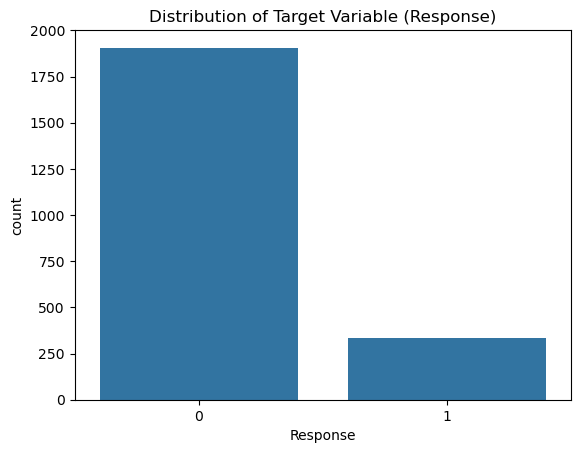

In [19]:
df["Response"].value_counts(normalize=True)

sns.countplot(x="Response", data=df)
plt.title("Distribution of Target Variable (Response)")
plt.show()

Since only 15% of customers responded to the campaign, the dataset is imbalanced. Accuracy would be misleading, as a model predicting all customers as non-responders would still achieve high accuracy (~85%). Therefore, ROC-AUC and PR-AUC were used as evaluation metrics, as they better capture the model’s ability to identify true responders.  

### 3. Data Quality and Missing values 
Assessing data quality is a critical step before model development. 
In this section, we examine missing values, detect potential inconsistencies, 
and evaluate whether corrective actions are required. 

#### 3.1 Missing values overview

In [8]:
df.isnull().sum().sort_values(ascending=False)   

Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Only the variable *Income* contains missing values (24 observations, ~1%).
No strong structural differences were observed between missing and non-missing groups.
Since the percentage is very low, removal is possible but imputation is preferable to preserve data, so median imputation will be applied during modeling.



#### 3.2 Income missing analysis

In [9]:
df["Income_missing"] = df["Income"].isna()
df.groupby("Income_missing")[["Recency","NumWebPurchases","NumStorePurchases"]].mean()

,Recency,NumWebPurchases,NumStorePurchases
Income_missing,,,
False,49.012635,4.085289,5.800993
True,58.041667,4.041667,4.791667


We compared customers with and without missing income values to assess whether the missingness could introduce bias.  

Customers with missing income show slightly higher recency (58 days vs 49 days), indicating that they have purchased somewhat less recently. They also present marginally lower store purchases, while web purchases remain nearly identical between groups.  

However, these differences are relatively small and the number of missing observations is low (~1% of the dataset). No clear structural pattern or demographic concentration was identified.  

Therefore, missingness appears approximately random, and simple median imputation will be applied during the modeling phase to avoid data leakage.

### 3.3 Income distribution and Outlier

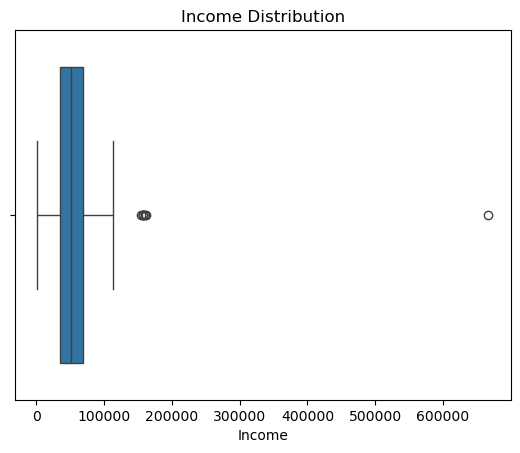

In [10]:
sns.boxplot(x=df["Income"])
plt.title("Income Distribution")
plt.show()

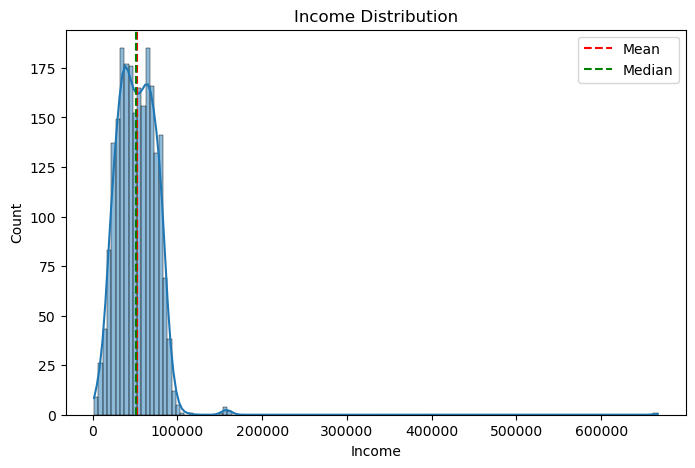

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], kde=True)
plt.axvline(df["Income"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Income"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.title("Income Distribution")
plt.show()

The Income variable is right-skewed and contains an extreme outlier (~666k). Since the mean is sensitive to extreme values, median imputation will be preferred to ensure robustness. Additionally, tree-based models are generally less sensitive to outliers.

Overall, the dataset contains minimal missing data (~1% in Income), and the missingness appears approximately random. Median imputation will therefore be applied during the modeling phase using a pipeline to prevent data leakage.

### 4. Feature Exploration 
To improve predictive performance and capture meaningful behavioral patterns, 
new features were created based on domain knowledge and business understanding.

These engineered variables aim to better represent customer value, 
engagement level, and historical campaign responsiveness.

#### 4.1 Behavioral Aggregated Features

To better capture customer value and historical responsiveness, 
two aggregated behavioral features were created:

- TotalSpend: represents overall customer expenditure across all product categories.
- PastCampaignAccepts: summarizes the number of previously accepted campaigns.

These features condense multiple related variables into more informative indicators, 
reducing dimensionality while preserving predictive signal.

Customers with higher total spending and prior campaign acceptance 
are expected to exhibit higher probability of responding to the new offer.

In [21]:
df["TotalSpend"] = df[
    ["MntWines","MntFruits","MntMeatProducts",
     "MntFishProducts","MntSweetProducts","MntGoldProds"]
].sum(axis=1)

df["PastCampaignAccepts"] = df[
    ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
     "AcceptedCmp4","AcceptedCmp5"]
].sum(axis=1)

**Income vs Response**  
Income is analyzed to determine whether higher purchasing power 
is associated with a greater likelihood of campaign acceptance.

Preliminary observations suggest that customers who responded 
tend to have slightly higher income levels, indicating 
that purchasing power may influence subscription decisions.

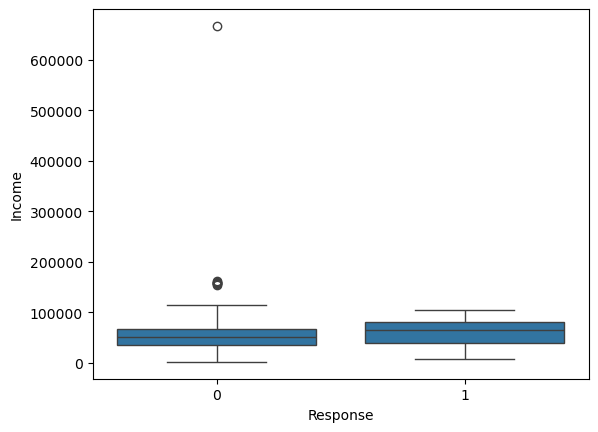

In [12]:
sns.boxplot(x="Response", y="Income", data=df)
plt.show()

**Recency vs Response**  
Recency measures the number of days since the customer's last purchase.

Customers with lower recency (more recent purchases) 
appear more likely to respond to the campaign, 
suggesting that recent engagement is an important behavioral signal.

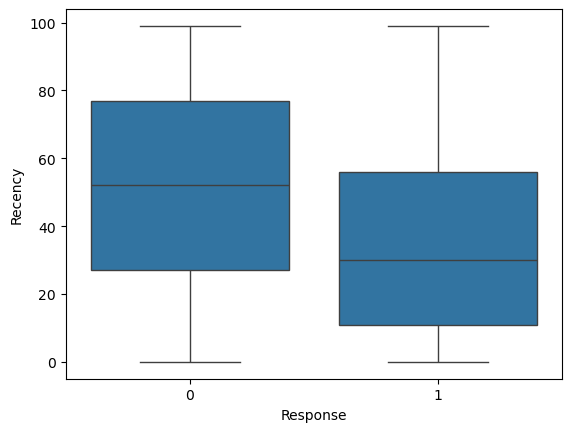

In [13]:
sns.boxplot(x="Response", y="Recency", data=df)
plt.show()

**Total Spend vs Response**  
Total Spend captures the overall monetary value 
of purchases across all product categories.

Responders generally exhibit higher total spending, 
indicating that high-value customers may be more receptive 
to subscription-based offers.


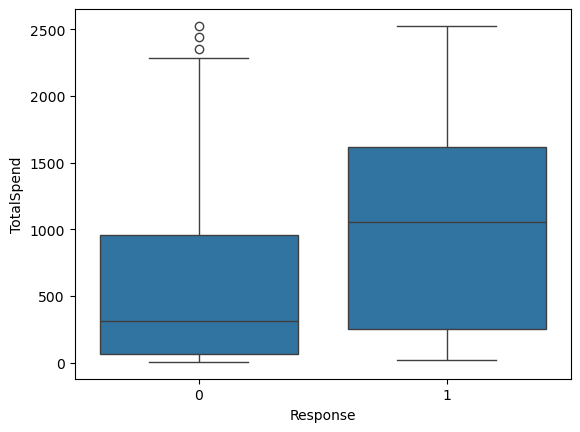

In [14]:
sns.boxplot(x="Response", y="TotalSpend", data=df)
plt.show()

**Past Campaing Accepts vs Response**  
Past Campaign Accepts summarizes historical campaign responsiveness.

A clear positive relationship is observed: customers who accepted 
previous campaigns are significantly more likely to accept the new offer.

This variable is expected to be one of the strongest predictors 
in the final machine learning model.

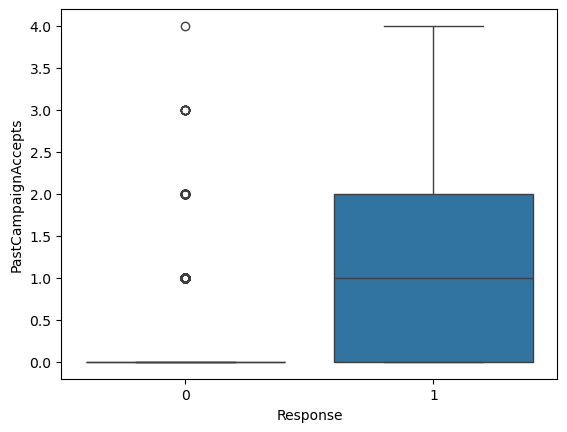

In [15]:
sns.boxplot(x="Response", y="PastCampaignAccepts", data=df)
plt.show()

### Key Predictive Patterns Identified

Campaign response is strongly associated with customer value and engagement. Responders tend to have higher income, higher total spending, and lower recency, indicating that recently active and high-value customers are more likely to accept the offer. Previous campaign acceptance emerges as one of the strongest behavioral predictors, suggesting consistency in responsiveness to marketing initiatives.

Income contains a small proportion of missing values (~1%), and no meaningful structural differences were observed between missing and non-missing customers. Therefore, median imputation will be applied during modeling without expected bias impact

## 6. Key Insights for Modeling

The exploratory analysis revealed several important patterns that will guide the modeling phase:

- The target variable is imbalanced (~15% positive responses), which suggests that evaluation metrics such as ROC-AUC, Precision-Recall AUC, and F1-score will be more appropriate than accuracy.

- Income contains a small proportion of missing values (~1%), and missingness appears approximately random. Median imputation will be applied within a modeling pipeline to prevent data leakage.

- The Income distribution is right-skewed and contains an extreme outlier. Tree-based models are expected to handle this robustly.

- Customers with lower Recency (more recent purchases) are more likely to respond, indicating that engagement recency is an important behavioral signal.

- Higher TotalSpend is associated with higher response probability, suggesting that high-value customers are more receptive to subscription offers.

- PastCampaignAccepts shows a strong positive relationship with Response and is expected to be one of the most predictive features.

Overall, behavioral and engagement-related variables appear more informative than purely demographic characteristics, reinforcing the importance of customer activity patterns in predicting campaign response.